# Image Classification: Dense Neural Network

[![Open In Colab <](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShawnHymel/computer-vision-with-embedded-machine-learning/blob/master/1.2.3%20-%20Training%20an%20Image%20Classifier%20with%20Keras/image_classifier_dnn.ipynb)

Run this notebook to train a dense neural network (DNN) on your own image dataset.

Based on: https://colab.research.google.com/github/AviatorMoser/keras-mnist-tutorial/blob/master/MNIST%20in%20Keras.ipynb#scrollTo=rFFriuVPwhAm

(I recommend working through the example above, as it has a lot of good descriptions on doing classification with images)

Create a folder named "dataset" in the /content directory and upload your images there. The images should be divided into their respective classes, where each class has its own folder with the name of the class. For example:

<pre>
/content
    |- dataset
        |- background
        |- capacitor
        |- diode
        |- led
        |- resistor
</pre>

Author: EdgeImpulse, Inc.<br>
Date: June 5, 2021<br>
License: [Apache-2.0](apache.org/licenses/LICENSE-2.0)<br>

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import PIL

from keras import utils                                   # tools for creating one-hot encoding
from keras.models import Sequential                       # Type of model we wish to use
from keras.layers import Dense, Dropout, Activation       # Types of layers we wish to use

from skimage.transform import resize                      # Used to scale/resize image arrays

from sklearn.metrics import confusion_matrix              # Used to quickly make confusion matrix

In [107]:
### Settings

# Location of dataset
DATASET_PATH = "/content/dataset"

# Desired resolution of images
TARGET_WIDTH = 28
TARGET_HEIGHT = 28

# Invert image (dark backgrounds can sometimes improve accuracy)
INVERT = False

# Set aside 20% for validation and 20% for test
VAL_RATIO = 0.2
TEST_RATIO = 0.2

# You are welcome to change the seed to try a different validation set split
random.seed(42)

In [108]:
# ----------- LOAD IMAGES AS NUMPY -----------

# define empty lists
labels = []
y_all = []
X_all = []


# Access class paths for further use
for label in os.listdir(DATASET_PATH):
  class_dir = os.path.join(DATASET_PATH, label)

  # remove un-needed class type: .ipynb_checkpoints
  if os.path.isdir(class_dir) and label != ".ipynb_checkpoints":
    labels.append(label)

  # Access each image files
  for i, file in enumerate(os.listdir(class_dir)):
    if file != ".ipynb_checkpoints":

      # Obtain the image file paths for injection into Python PIL library
      file_path = os.path.join(class_dir, file)
      img = PIL.Image.open(file_path).convert("L")


    # Convert PIL image into Numpy arrayInvert the image colors so that white becomes black and vice versa
    img_array = np.asarray(img)

    if INVERT:
      img_array = 255 - img_array
    X_all.append(img_array)


    # Add label to Label list
    y_all.append(label)

  print(f"Added {1 + i} numbers of images from {label}")


# total number of image dataset
num_img = len(X_all)
# Arrange Labels Alphabetically
labels = sorted(labels)

print("\n\n======================================\n\n")
print(f"Total number of image dataset is {num_img}")
print(f"Sorted labels: {labels}")








Added 50 numbers of images from resistor
Added 50 numbers of images from background
Added 50 numbers of images from led
Added 50 numbers of images from capacitor
Added 50 numbers of images from .ipynb_checkpoints
Added 50 numbers of images from diode




Total number of image dataset is 250
Sorted labels: ['background', 'capacitor', 'diode', 'led', 'resistor']


In [109]:
# ---------- CONVERT ALL LABELS TO NUMBERS --------------

# label before conversion
print(f"Before: {y_all}")

y_out = []
for i, label in enumerate(y_all):
  y_num = labels.index(label)
  y_out.append(y_num)

y_all = y_out

# labels after conversion to number
print(f"After: {y_all}")




Before: ['resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'resistor', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background', 'background',

In [110]:
# -------- DATA SHUFFLING, SPLITING ----------


# Shuffle X and y together
X_y = list(zip(X_all, y_all))
random.shuffle(X_y)
X_all, y_all = zip(*X_y)


# Calculate the number of each splits
num_test_split = int(TEST_RATIO * num_img)
num_val_split = int(VAL_RATIO * num_img)


# Spliting into Test Splits
X_test = X_all[:num_test_split]
y_test = y_all[:num_test_split]

# Spliting into Validation splits
X_val = X_all[num_test_split: (num_test_split + num_val_split)]
y_val = y_all[num_test_split: (num_test_split + num_val_split)]

# Using the remaining split as Training Set
X_train = X_all[(num_test_split + num_val_split): ]
y_train = y_all[(num_test_split + num_val_split): ]


# Number of image samples in the training set
num_samples_train = len(X_train)



print(f"Number of Samples in Training Set: {num_samples_train}")
print(f"Number of Samples in Testing Set: {num_test_split}")
print(f"Number of Samples in Validation Set: {num_val_split}")

Number of Samples in Training Set: 150
Number of Samples in Testing Set: 50
Number of Samples in Validation Set: 50


Label: 2 | Label name: diode
[[146 146 146 ... 146 146 146]
 [146 146 146 ... 146 146 146]
 [146 146 146 ... 146 146 146]
 ...
 [146 151 151 ... 151 151 146]
 [146 151 151 ... 151 151 146]
 [149 149 149 ... 151 151 151]]


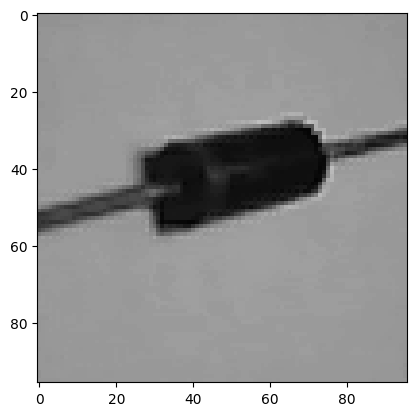

In [111]:
# --------- VIEW ONE OF THE TRAINING SAMPLE IMAGE ------------

idx = 10


# print the label number and name
print(f"Label: {y_train[idx]} | Label name: {labels[y_train[idx]]}")

# Print some of image number in numpy array
print(X_train[idx])

plt.imshow(
    X_train[idx],
    cmap= 'gray',
    vmin= 0,
    vmax = 255
    );

In [112]:
# ------------ Function to resize list of images --------------


def resize_images(images, width, height, anti_aliasing=True):
  """
  Prove a list of Numpy arrays (in images parameter) to have them all resized to desired height and
  width. Returns the list of newly resized image arrays.

  NOTE: skimage resize returns *normalized* image arrays (values between 0..1)
  """
  X_out = []
  for i, img in enumerate(images):
    X_out.append(resize(img, (height, width), anti_aliasing=anti_aliasing))
  return X_out

In [113]:
### Scale/crop images

# Resize (scale) all images in the training set
X_train = resize_images(X_train, TARGET_WIDTH, TARGET_HEIGHT)

# Resize (scale) all images in the validation set
X_val = resize_images(X_val, TARGET_WIDTH, TARGET_HEIGHT)

# Resize (scale) all images in the test set
X_test = resize_images(X_test, TARGET_WIDTH, TARGET_HEIGHT)

Label: 2 | Label name: diode
[[0.57331562 0.57542771 0.57620016 0.58154335 0.58680476 0.59159661
  0.5898274  0.59087842 0.59050268 0.59000904 0.59680306 0.59682001
  0.5962286  0.59706878 0.59906726 0.60297283 0.60011607 0.59919682
  0.59543662 0.59319532 0.58950852 0.58713237 0.58982915 0.58586559
  0.58635842 0.57949888 0.57740644 0.57304383]]


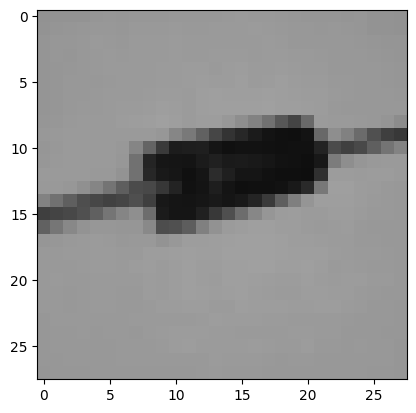

In [114]:
# --------- VIEW ONE OF THE TRAINING SAMPLE IMAGE ------------

idx = 10


# print the label number and name
print(f"Label: {y_train[idx]} | Label name: {labels[y_train[idx]]}")

# Print some of image number in numpy array
print(X_train[idx][:1, : ])

plt.imshow(
    X_train[idx],
    cmap= 'gray',
    vmin= 0,
    vmax = 1
    );

In [115]:
# ---------- CONVERT LIST TO NUMPY ARRAY -------------

# Training Set
X_train = np.asarray(X_train)
y_train = np.asarray(y_train)

# Validation Set
X_val = np.asarray(X_val)
y_val = np.asarray(y_val)

# Test Set
X_test = np.asarray(X_test)
y_test = np.asarray(y_test)


# Print out the new Numpy array shapes (always a good idea to check the shapes!)
print("Training X:", X_train.shape)
print("Training y:", y_train.shape)
print("Validation X:", X_val.shape)
print("Validation y:", y_val.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Training X: (150, 28, 28)
Training y: (150,)
Validation X: (50, 28, 28)
Validation y: (50,)
Test X: (50, 28, 28)
Test y: (50,)


In [123]:
# ------- FLATTEN IMAGES TO 1D VECTOR -----------


# Compute Length of 1D array that we want to flatten each image to
len_vector = TARGET_WIDTH * TARGET_HEIGHT

# Flatten Matrices to Vectors
X_train = X_train.reshape(num_samples_train, len_vector)
X_val = X_val.reshape(num_val_split, len_vector)
X_test = X_test.reshape(num_test_split, len_vector)


# Determine the input shape
input_shape = (X_train.shape[1], )


# Print out shapes
print("X train:", X_train.shape)
print("y train:", y_train.shape)
print("X val:", X_val.shape)
print("y val:", y_val.shape)
print("X test:", X_test.shape)
print("y test:", y_test.shape)
print("Input tensor shape:", input_shape)

X train: (150, 784)
y train: (150,)
X val: (50, 784)
y val: (50,)
X test: (50, 784)
y test: (50,)
Input tensor shape: (784,)


In [133]:
# --------- CONVERT LABEL (INTEGERS) TO ONE-HOT ENCODING --------------

# number of classes
num_classes = len(labels)


# Create one hot encoding using keras np_utils
Y_train = utils.to_categorical(y_train, num_classes)
Y_val = utils.to_categorical(y_val, num_classes)
Y_test = utils.to_categorical(y_test, num_classes)

# Print out shapes (capital 'Y' is our one-hot matrix!)
print("Y train:", Y_train.shape)
print("Y val:", Y_val.shape)
print("Y test:", Y_test.shape)

print("\n\n------------------\n\n")

# Print out a few examples from training set
for i in range(10):
  print("Label: " + str(y_train[i]) + " | One-hot:", Y_train[i])

Y train: (150, 5)
Y val: (50, 5)
Y test: (50, 5)


------------------


Label: 3 | One-hot: [0. 0. 0. 1. 0.]
Label: 3 | One-hot: [0. 0. 0. 1. 0.]
Label: 2 | One-hot: [0. 0. 1. 0. 0.]
Label: 2 | One-hot: [0. 0. 1. 0. 0.]
Label: 2 | One-hot: [0. 0. 1. 0. 0.]
Label: 4 | One-hot: [0. 0. 0. 0. 1.]
Label: 3 | One-hot: [0. 0. 0. 1. 0.]
Label: 1 | One-hot: [0. 1. 0. 0. 0.]
Label: 3 | One-hot: [0. 0. 0. 1. 0.]
Label: 4 | One-hot: [0. 0. 0. 0. 1.]


In [138]:
# -------- CONSTRUCT KERAS MODEL ------------

# sequential model
model = Sequential()

# First Layer
model.add(Dense(64, input_shape=input_shape))
model.add(Activation('relu'))
model.add(Dropout(0.25))

# second Layer:
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.25))

# output layer:
model.add(Dense(num_classes))
model.add(Activation('softmax'))


# Compile Model
model.compile(loss= 'categorical_crossentropy', optimizer = 'adam', metrics=['acc'])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,725 (213.77 KB)

 Trainable params: 54,725 (213.77 KB)

 Non-trainable params: 0 (0.00 B)

None


In [139]:
# -------- TRAIN MODEL --------------

history = model.fit(
    X_train,
    Y_train,
    batch_size=32,
    epochs = 200,
    verbose = 1,
    validation_data= (X_val, Y_val)
)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - acc: 0.2600 - loss: 1.6496 - val_acc: 0.2200 - val_loss: 1.6204
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.2800 - loss: 1.5961 - val_acc: 0.4000 - val_loss: 1.5546
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.2667 - loss: 1.5619 - val_acc: 0.3800 - val_loss: 1.5412
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.2800 - loss: 1.5260 - val_acc: 0.4000 - val_loss: 1.5061
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.3800 - loss: 1.4953 - val_acc: 0.4800 - val_loss: 1.4900
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.3800 - loss: 1.4832 - val_acc: 0.5000 - val_loss: 1.4477
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.4800 - loss: 1.3783 - val_acc: 0.4800 - val_loss: 1.4089
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - acc: 0.5267 - loss: 1.3410 - val_acc: 0.6200 - val_loss: 1.3397
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.5733 - loss:

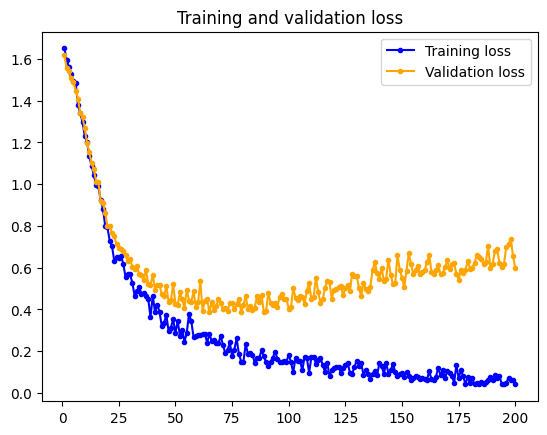

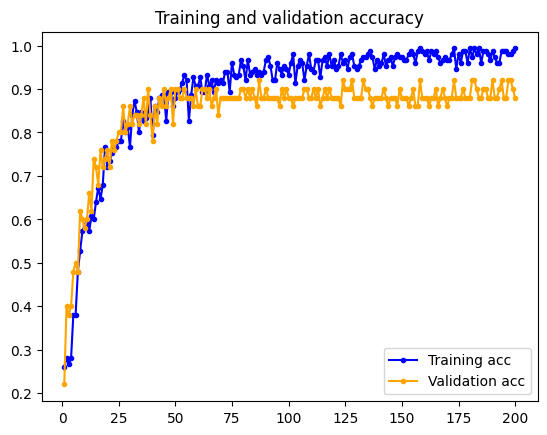

In [140]:
### Plot training and validation accuracy and loss over time

# Extract accuracy and loss values (in list form) from the history
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a list of epoch numbers
epochs = range(1, len(acc) + 1)

# Plot training and validation loss values over time
plt.figure()
plt.plot(epochs, loss, color='blue', marker='.', label='Training loss')
plt.plot(epochs, val_loss, color='orange', marker='.', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

# Plot training and validation accuracies over time
plt.figure()
plt.plot(epochs, acc, color='blue', marker='.', label='Training acc')
plt.plot(epochs, val_acc, color='orange', marker='.', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

In [141]:
### Try predicting label with one validation sample (inference)

# Change this to try a different sample from the test set
idx = 0

# Make sample 2D array instead of 1D vector (this is what the Keras model expects as input)
x = np.expand_dims(X_val[idx], 0)

# Make prediction using trained model
y_pred = model.predict(x)

# Find index of highest score in output
predicted_label = np.argmax(y_pred)
actual_label = np.argmax(Y_val[idx])

# Display model output, predicted label, actual label
print("Model output:", y_pred)
print("Predicted label:", predicted_label, "-", labels[predicted_label])
print("Actual label:", actual_label, "-", labels[actual_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Model output: [[8.7756948e-09 1.7333765e-05 1.4883681e-06 9.9981421e-01 1.6698129e-04]]
Predicted label: 3 - led
Actual label: 3 - led


In [142]:
### Create confusion matrix from validation set

# Find predictions from all validation samples
Y_pred = model.predict(X_val)
print("Validation output shape:", Y_pred.shape)

# Convert actual and predicted validation one-hot encoding to numerical labels
y_val = np.argmax(Y_val, axis=1)
y_pred = np.argmax(Y_pred, axis=1)

# Print some values from actual and predicted validation sets (first 50 samples)
print("Actual validation labels:\t", y_val[:50])
print("Predicted validation labels:\t", y_pred[:50])

# Compute confusion matrix (note: we need to transpose SKLearn matrix to make it match Edge Impulse)
cm = confusion_matrix(y_val, y_pred)
cm = np.transpose(cm)

# Print confusion matrix
print()
print(" ---> Predicted labels")
print("|")
print("v Actual labels")
print("\t\t\t" + ' '.join("{!s:6}".format('(' + str(i) + ')') for i in range(num_classes)))
for row in range(num_classes):
  print("{:>12} ({}):  [{}]".format(labels[row], row, ' '.join("{:6}".format(i) for i in cm[row])))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Validation output shape: (50, 5)
Actual validation labels:	 [3 3 1 3 4 0 2 0 2 4 0 3 3 3 2 4 2 4 2 4 1 1 2 3 1 2 4 2 1 0 0 4 1 4 2 2 0
 4 4 1 1 2 4 3 1 0 4 3 2 2]
Predicted validation labels:	 [3 3 1 4 4 0 2 0 2 4 0 3 3 3 2 4 2 4 2 4 1 1 2 4 1 2 1 2 1 0 0 2 1 4 2 4 0
 4 4 1 1 2 1 3 1 0 4 3 2 2]

 ---> Predicted labels
|
v Actual labels
			(0)    (1)    (2)    (3)    (4)   
  background (0):  [     7      0      0      0      0]
   capacitor (1):  [     0      9      0      0      2]
       diode (2):  [     0      0     12      0      1]
         led (3):  [     0      0      0      7      0]
    resistor (4):  [     0      0      1      2      9]


In [143]:
### Evaluate model on validation set
score = model.evaluate(X_val, Y_val)
print("Validation loss:", score[0])
print("Validation accuracy:", score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.8800 - loss: 0.5962
Validation loss: 0.5962408185005188
Validation accuracy: 0.8799999952316284


In [144]:
### Evaluate model on entire test set
score = model.evaluate(X_test, Y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.8800 - loss: 0.2678
Test loss: 0.2677968144416809
Test accuracy: 0.8799999952316284
